# Differentiable Rendering with jaxCAD's Parameter System

jaxCAD's sphere-tracing renderer is fully differentiable — gradients flow through the
march loop, normal computation, and shading. This notebook solves an **inverse-rendering
problem**: given a target photograph (`lada.png`), optimise a scene of SDF primitives so
its rendering minimises pixel-space MSE against the photo.

The full pipeline uses jaxCAD's parameter system end-to-end:

1. Build a `Scene` with geometry, per-primitive `Material`s (colours as free `Vector`
   params), a `Camera`, and lighting.
2. `extract_parameters(scene)` yields one `free_params` dict covering geometry,
   materials, camera, and lights — no manual bookkeeping.
3. `functionalize_render(scene)` compiles the scene to a pure
   `(free_params, resolution) → image` JAX function, differentiable via `jax.grad`.
4. Adam optimises `free_params` to minimise pixel-space MSE against the target.

Material colours are stored in `[0, 1]` linear space.  The background colour
(`bg_color`) is the exception: it lives in logit space and is sigmoid-mapped at
render time so it stays unconstrained during optimisation.

In [1]:
import time

import imageio
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
from PIL import Image

from jaxcad import (
    compute_param_scales,
    extract_parameters,
    from_normalized,
    functionalize_render,
    to_normalized,
)
from jaxcad.geometry import Scalar, Vector
from jaxcad.render import Camera, Material, Scene
from jaxcad.sdf import Box, Cylinder, Plane, Rotate, RoundBox, Torus, Translate, Union

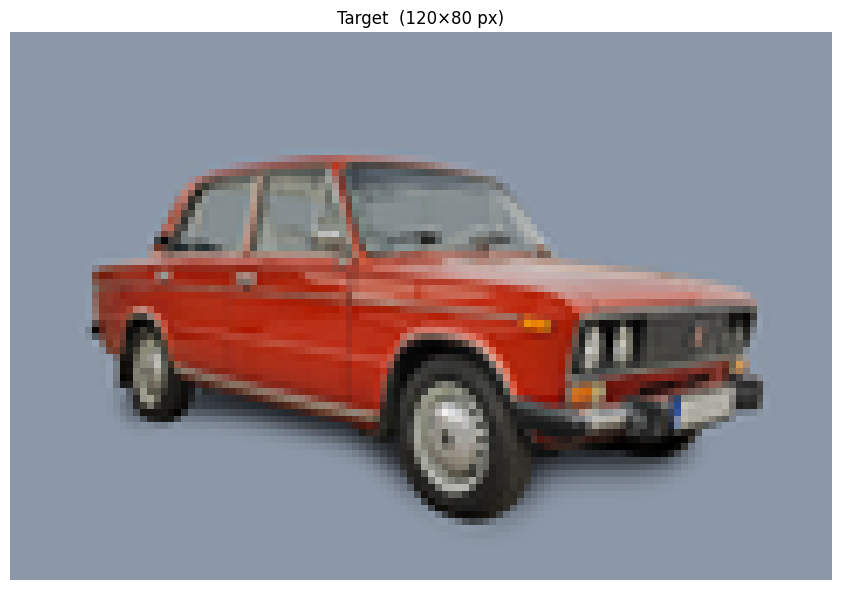

In [2]:
# ── Target image ─────────────────────────────────────────────────────────────
RES = (80, 120)  # (height, width)
SKY = (140, 152, 168)

img_rgba = Image.open("assets/lada.png").convert("RGBA")
bg = Image.new("RGB", img_rgba.size, SKY)
bg.paste(img_rgba.convert("RGB"), mask=img_rgba.split()[3])
target_pil = bg.resize((RES[1], RES[0]), Image.LANCZOS)

target = jnp.array(np.array(target_pil) / 255.0, dtype=jnp.float32)

fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(np.array(target))
ax.set_title(f"Target  ({RES[1]}×{RES[0]} px)")
ax.axis("off")
plt.tight_layout()
plt.show()

In [3]:
# ── Free geometry parameters ──────────────────────────────────────────────────

# Lower body (chassis + doors)
body_pos = Vector([0.0, -0.10, 0.0], free=True, name="body_pos")
body_size = Vector([1.85, 0.42, 0.65], free=True, name="body_size", bounds=(0.01, None))

# Cabin — roof slab + front A-pillar + rear C-pillar, each with a free rotation angle
roof_pos = Vector([-0.15, 0.90, 0.0], free=True, name="roof_pos")
roof_size = Vector([0.82, 0.11, 0.58], free=True, name="roof_size", bounds=(0.01, None))

pillar_f_pos = Vector([-0.65, 0.67, 0.0], free=True, name="pillar_f_pos")
pillar_f_size = Vector([0.13, 0.25, 0.55], free=True, name="pillar_f_size", bounds=(0.01, None))
pillar_f_angle = Scalar(0.25, free=True, name="pillar_f_angle")  # lean (rad), around Z

pillar_r_pos = Vector([0.42, 0.67, 0.0], free=True, name="pillar_r_pos")
pillar_r_size = Vector([0.13, 0.25, 0.55], free=True, name="pillar_r_size", bounds=(0.01, None))
pillar_r_angle = Scalar(-0.22, free=True, name="pillar_r_angle")  # lean (rad), around Z

# Hood — free size, position, and slope angle (nose-down = negative)
hood_pos = Vector([-1.47, 0.18, 0.0], free=True, name="hood_pos")
hood_size = Vector([0.62, 0.12, 0.63], free=True, name="hood_size", bounds=(0.01, None))
hood_angle = Scalar(-0.08, free=True, name="hood_angle")

# Trunk lid — free size, position, and slope angle
trunk_pos = Vector([1.35, 0.14, 0.0], free=True, name="trunk_pos")
trunk_size = Vector([0.48, 0.09, 0.63], free=True, name="trunk_size", bounds=(0.01, None))
trunk_angle = Scalar(0.06, free=True, name="trunk_angle")

# Bumpers
bumper_f_pos = Vector([-1.96, -0.20, 0.0], free=True, name="bumper_f_pos")
bumper_r_pos = Vector([1.96, -0.20, 0.0], free=True, name="bumper_r_pos")
bumper_size = Vector([0.04, 0.18, 0.58], free=True, name="bumper_size", bounds=(0.01, None))
bumper_radius = Scalar(0.06, free=True, name="bumper_radius", bounds=(0.001, None))

# Wheel positions (near-side, disc face toward +Z camera)
wf_pos = Vector([-1.15, -0.65, 0.52], free=True, name="wf_pos")
wr_pos = Vector([1.15, -0.65, 0.52], free=True, name="wr_pos")

# Tire — Torus in XY plane (Z = wheel symmetry axis)
r_tire_major = Scalar(0.34, free=True, name="r_tire_major", bounds=(0.05, None))
r_tire_minor = Scalar(0.08, free=True, name="r_tire_minor", bounds=(0.01, None))

# Rim disc (aluminium face)
r_rim = Scalar(0.28, free=True, name="r_rim", bounds=(0.02, None))
wh_rim = Scalar(0.10, free=True, name="wh_rim", bounds=(0.01, None))

# Central hub boss
r_hub = Scalar(0.08, free=True, name="r_hub", bounds=(0.01, None))
wh_hub = Scalar(0.16, free=True, name="wh_hub", bounds=(0.01, None))

# Materials
body_mat = Material("body_mat", color=[0.50, 0.50, 0.50], roughness=0.40, metallic=0.12, free=True)
roof_mat = Material("roof_mat", color=[0.50, 0.50, 0.50], roughness=0.35, metallic=0.08, free=True)
pillar_mat = Material(
    "pillar_mat", color=[0.10, 0.10, 0.10], roughness=0.60, metallic=0.05, free=True
)
hood_mat = Material("hood_mat", color=[0.50, 0.50, 0.50], roughness=0.38, metallic=0.12, free=True)
tire_mat = Material("tire_mat", color=[0.08, 0.08, 0.08], roughness=0.88, metallic=0.00, free=True)
rim_mat = Material("rim_mat", color=[0.75, 0.75, 0.80], roughness=0.18, metallic=0.92, free=True)
bump_mat = Material("bump_mat", color=[0.72, 0.72, 0.72], roughness=0.50, metallic=0.25, free=True)
ground_mat = Material(
    "ground_mat", color=[0.40, 0.40, 0.40], roughness=0.95, metallic=0.00, free=True
)

# ── Ground plane ──────────────────────────────────────────────────────────────
GROUND_Y = -1.10
ground = Plane(height=Scalar(GROUND_Y, free=False), material=ground_mat)


# ── Wheel assembly: rubber torus + aluminium rim disc + hub boss ───────────────
def make_wheel(pos):
    tire = Translate(
        Torus(major_radius=r_tire_major, minor_radius=r_tire_minor, material=tire_mat), pos
    )
    rim = Translate(Cylinder(radius=r_rim, height=wh_rim, material=rim_mat), pos)
    hub = Translate(Cylinder(radius=r_hub, height=wh_hub, material=rim_mat), pos)
    return Union((tire, rim, hub), smoothness=0.0)


car = Union(
    (
        # ── Body ─────────────────────────────────────────────────────────────
        Translate(Box(size=body_size, material=body_mat), body_pos),
        # ── Cabin: roof + A-pillar (front) + C-pillar (rear) ─────────────────
        Translate(Box(size=roof_size, material=roof_mat), roof_pos),
        Translate(
            Rotate(
                RoundBox(size=pillar_f_size, radius=0.03, material=pillar_mat), "z", pillar_f_angle
            ),
            pillar_f_pos,
        ),
        Translate(
            Rotate(
                RoundBox(size=pillar_r_size, radius=0.03, material=pillar_mat), "z", pillar_r_angle
            ),
            pillar_r_pos,
        ),
        # ── Hood (sloped) ─────────────────────────────────────────────────────
        Translate(Rotate(Box(size=hood_size, material=hood_mat), "z", hood_angle), hood_pos),
        # ── Trunk lid (sloped) ────────────────────────────────────────────────
        Translate(Rotate(Box(size=trunk_size, material=hood_mat), "z", trunk_angle), trunk_pos),
        # ── Bumpers ───────────────────────────────────────────────────────────
        Translate(
            RoundBox(size=bumper_size, radius=bumper_radius, material=bump_mat), bumper_f_pos
        ),
        Translate(
            RoundBox(size=bumper_size, radius=bumper_radius, material=bump_mat), bumper_r_pos
        ),
        # ── Near-side wheels (tire + rim + hub) ───────────────────────────────
        make_wheel(wf_pos),
        make_wheel(wr_pos),
    ),
    smoothness=0.05,
)

geometry = Union((car, ground), smoothness=0.0)

# ── Camera and scene ──────────────────────────────────────────────────────────
camera = Camera(
    camera_pos=Vector([4.0, 2.0, 6.0], free=True, name="camera_pos"),
    look_at=Vector([0.0, 0.0, 0.0], free=False, name="look_at"),
    fov=Scalar(0.55, free=False, name="fov"),
)

scene = Scene(
    geometry,
    camera,
    bg_color=Vector([0.5, 0.5, 0.5], free=True, name="bg_color"),
    light_dirs=[
        Vector([0.45, 0.85, 0.25], free=True, name="light_dir_0"),
        Vector([-0.3, 0.5, -0.2], free=True, name="light_dir_1"),
    ],
    light_colors=[
        Vector([0.90, 0.90, 0.90], free=True, name="light_color_0", bounds=(0.0, None)),
        Vector([0.35, 0.35, 0.35], free=True, name="light_color_1", bounds=(0.0, None)),
    ],
)

# ── Extract all free parameters ───────────────────────────────────────────────
free_params, fixed_params, metadata = extract_parameters(scene)

print("free_params keys:", sorted(free_params.keys()))
print(
    f"\n{len(free_params)} free params, "
    f"{sum(v.size for v in free_params.values())} scalar values"
)
bounded = {k: p.bounds for k, p in metadata.items() if p.bounds is not None}
print(f"\nBounded params ({len(bounded)}): {bounded}")

free_params keys: ['bg_color', 'body_mat_color', 'body_mat_ior', 'body_mat_metallic', 'body_mat_opacity', 'body_mat_reflectivity', 'body_mat_roughness', 'body_pos', 'body_size', 'bump_mat_color', 'bump_mat_ior', 'bump_mat_metallic', 'bump_mat_opacity', 'bump_mat_reflectivity', 'bump_mat_roughness', 'bumper_f_pos', 'bumper_r_pos', 'bumper_radius', 'bumper_size', 'camera_pos', 'ground_mat_color', 'ground_mat_ior', 'ground_mat_metallic', 'ground_mat_opacity', 'ground_mat_reflectivity', 'ground_mat_roughness', 'hood_angle', 'hood_mat_color', 'hood_mat_ior', 'hood_mat_metallic', 'hood_mat_opacity', 'hood_mat_reflectivity', 'hood_mat_roughness', 'hood_pos', 'hood_size', 'light_color_0', 'light_color_1', 'light_dir_0', 'light_dir_1', 'pillar_f_angle', 'pillar_f_pos', 'pillar_f_size', 'pillar_mat_color', 'pillar_mat_ior', 'pillar_mat_metallic', 'pillar_mat_opacity', 'pillar_mat_reflectivity', 'pillar_mat_roughness', 'pillar_r_angle', 'pillar_r_pos', 'pillar_r_size', 'r_hub', 'r_rim', 'r_tire_m

Rendering initial scene (first run triggers XLA compilation)...
Output shape: (80, 120, 3)


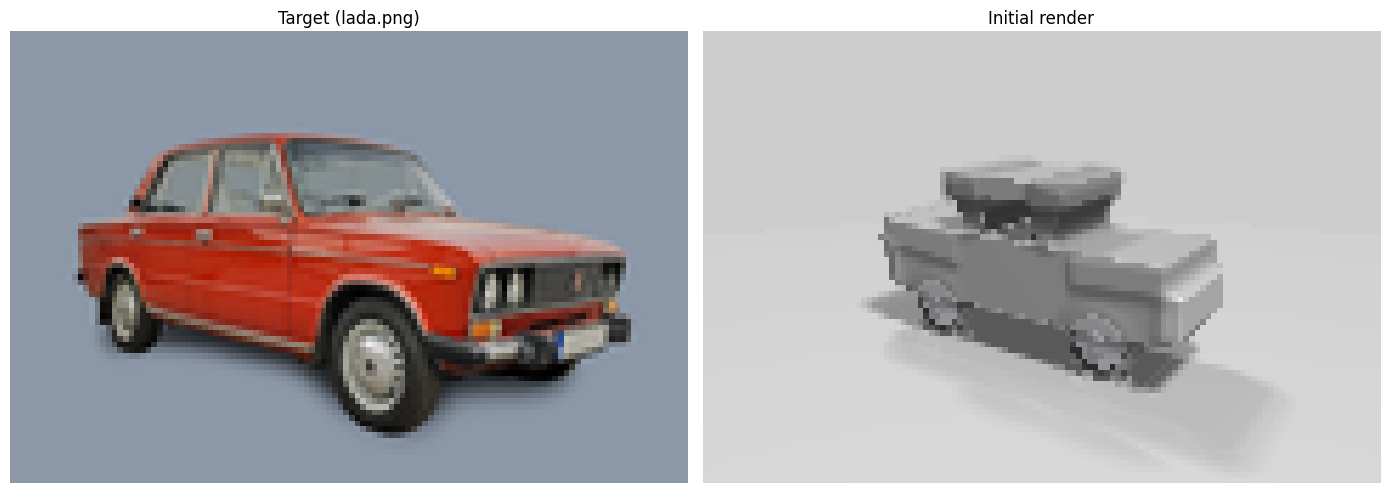

In [4]:
# ── Compile the scene to a differentiable render function ─────────────────────
#
# functionalize_render walks the geometry + material tree, builds pure JAX
# closures for the SDF and material_fn, and wires them into the sphere-tracing
# renderer. The result is a plain function that jax.grad can differentiate
# through entirely.

diff_render = functionalize_render(
    scene,
    max_steps=32,
    shadow_steps=12,
    shadow_hardness=6.0,
    gamma=2.2,
    fd_normals=False,
)

print("Rendering initial scene (first run triggers XLA compilation)...")
img0 = diff_render(free_params, resolution=RES)
print(f"Output shape: {img0.shape}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(np.array(target))
axes[0].set_title("Target (lada.png)")
axes[0].axis("off")
axes[1].imshow(np.array(img0))
axes[1].set_title("Initial render")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Optimisation

We minimise MS-SSIM loss with AdamW and two improvements over a plain fixed-LR loop:

1. **Cosine LR decay** — learning rate anneals smoothly from `3e-4` to `0` over all
   steps, avoiding late-stage instability.
2. **Coarse-to-fine rendering** — three phases at increasing resolution (40×60 →
   60×90 → 80×120).  Early low-res steps are cheap and escape coarse geometry minima;
   later high-res steps refine details.  Adam momentum carries over across phases so
   convergence isn't reset.

In [5]:
# --- SSIM loss utilities ---


def _ssim_channel(x, y, win_size=3, C1=1e-4, C2=9e-4):
    """SSIM between two (H, W) arrays using a uniform window."""
    pad = win_size // 2
    k = jnp.ones((win_size, win_size)) / win_size**2

    def filt2d(img):
        n = img[None, None]  # (1, 1, H, W)
        f = k[None, None]  # (1, 1, win, win)
        return jax.lax.conv_general_dilated(
            n,
            f,
            (1, 1),
            padding=((pad, pad), (pad, pad)),
            dimension_numbers=("NCHW", "OIHW", "NCHW"),
        )[0, 0]

    mu_x = filt2d(x)
    mu_y = filt2d(y)
    # clamp to 0 — float32 subtraction can produce tiny negatives in flat regions
    s_x2 = jnp.maximum(filt2d(x * x) - mu_x**2, 0.0)
    s_y2 = jnp.maximum(filt2d(y * y) - mu_y**2, 0.0)
    s_xy = filt2d(x * y) - mu_x * mu_y

    num = (2 * mu_x * mu_y + C1) * (2 * s_xy + C2)
    den = (mu_x**2 + mu_y**2 + C1) * (s_x2 + s_y2 + C2)
    # average numerator/denominator separately to avoid NaN from pointwise near-zero den
    return jnp.sum(num) / jnp.maximum(jnp.sum(den), 1e-8)


def ms_ssim_loss(rendered, target, scales=(1, 2, 3, 4)):
    """Multi-scale SSIM loss (average of 1-SSIM across scales and channels)."""
    # vmap over the channel axis — one traced graph instead of three
    ssim_per_channel = jax.vmap(_ssim_channel, in_axes=(2, 2))

    total = 0.0
    for s in scales:
        if s > 1:
            H, W, _ = rendered.shape
            r = jax.image.resize(rendered, (H // s, W // s, 3), method="linear")
            t = jax.image.resize(target, (H // s, W // s, 3), method="linear")
        else:
            r, t = rendered, target
        total += 1.0 - jnp.mean(ssim_per_channel(r, t))
    return total / len(scales)

In [6]:
# ── Parameter space setup ─────────────────────────────────────────────────────
# Two composable layers between raw params and the optimizer:
#
#   free_params ──► to_unconstrained ──► normalize ──► Lion optimizes here
#                                                            │
#   free_params ◄── to_constrained  ◄── unnormalize ◄───────┘
#
# to_normalized / from_normalized are imported from jaxcad.parametrization.
# compute_param_scales assigns scale=1.0 to fully-bounded params (sigmoid maps
# them to O(1–4) already) and scale=SCENE_SCALE to lower-bounded/unbounded
# params so the optimizer always works in an approximately O(1) space.

SCENE_SCALE = 2.0  # characteristic scene length — tune if needed
scales = compute_param_scales(metadata, scene_scale=SCENE_SCALE)

# Sanity-check: print per-param min/max in normalized space
normalized_init = to_normalized(free_params, metadata, scales)
print(f"{'param':<30}  {'min':>8}  {'max':>8}")
for k, v in sorted(normalized_init.items()):
    print(f"  {k:<28}  {float(jnp.min(v)):>8.3f}  {float(jnp.max(v)):>8.3f}")

# Round-trip sanity check
rt = from_normalized(normalized_init, metadata, scales)
max_err = max(float(jnp.max(jnp.abs(rt[k] - free_params[k]))) for k in free_params)
print(f"\nRound-trip max error: {max_err:.2e}  (should be < 1e-5)")

param                                min       max
  bg_color                         0.250     0.250
  body_mat_color                   0.000     0.000
  body_mat_ior                   -13.816   -13.816
  body_mat_metallic               -1.992    -1.992
  body_mat_opacity                13.802    13.802
  body_mat_reflectivity          -13.816   -13.816
  body_mat_roughness              -0.405    -0.405
  body_pos                        -0.050     0.000
  body_size                       -0.340     0.834
  bump_mat_color                   0.944     0.944
  bump_mat_ior                   -13.816   -13.816
  bump_mat_metallic               -1.099    -1.099
  bump_mat_opacity                13.802    13.802
  bump_mat_reflectivity          -13.816   -13.816
  bump_mat_roughness               0.000     0.000
  bumper_f_pos                    -0.980     0.000
  bumper_r_pos                    -0.100     0.980
  bumper_radius                   -1.400    -1.400
  bumper_size                  

In [ ]:
# ── Coarse-to-fine optimisation with cosine LR decay ─────────────────────────
phases = [
    {"resolution": (40, 60), "steps": 4000, "max_steps": 16, "shadow_steps": 6},
    {"resolution": (120, 180), "steps": 2000, "max_steps": 48, "shadow_steps": 16},
]
N_STEPS = sum(p["steps"] for p in phases)

# Lion + normalized params — no bounds projection needed
schedule = optax.cosine_decay_schedule(init_value=3e-4, decay_steps=N_STEPS)
optimizer = optax.lion(schedule, weight_decay=1e-3)

# Work in normalized space; bounds enforced via sigmoid/softplus, scale via `scales`
params = to_normalized(free_params, metadata, scales)
opt_state = optimizer.init(params)

losses = []
grad_norms = []
snapshots = {}
step_global = 0

print(f"{'Phase':<8} {'Res':>10}  {'Steps':>6}  {'march':>6}  {'shadow':>7}")
for p in phases:
    r = p["resolution"]
    print(
        f"  {phases.index(p)+1}/{len(phases)}    {r[1]}×{r[0]:>3}    {p['steps']:>5}    {p['max_steps']:>4}    {p['shadow_steps']:>5}"
    )
print(
    f"\nTotal steps: {N_STEPS}   LR: cosine 3e-4 → 0 (Lion)   weight_decay=1e-3   bounds: sigmoid/softplus+scale"
)


def make_step_fn(render_fn, res, tgt, optimizer):
    """JIT-compile the full step: forward + backward + optimizer update + grad stats."""

    def loss_fn(normalized_p):
        p = from_normalized(normalized_p, metadata, scales)
        rendered = render_fn(p, resolution=res)
        return ms_ssim_loss(rendered, tgt)

    val_and_grad = jax.value_and_grad(loss_fn)

    @jax.jit
    def step(params, opt_state):
        val, grads = val_and_grad(params)
        leaves = jax.tree.leaves(grads)
        grad_norm = jnp.sqrt(sum(jnp.sum(g**2) for g in leaves))
        grad_max = jnp.max(jnp.stack([jnp.max(jnp.abs(g)) for g in leaves]))
        grad_min = jnp.min(jnp.stack([jnp.min(jnp.abs(g)) for g in leaves]))
        has_nan = jnp.isnan(val) | jnp.any(jnp.stack([jnp.any(jnp.isnan(g)) for g in leaves]))
        updates, new_opt_state = optimizer.update(grads, opt_state, params)
        new_params = optax.apply_updates(params, updates)
        return new_params, new_opt_state, val, grads, grad_norm, grad_max, grad_min, has_nan

    return step


for phase_idx, phase in enumerate(phases):
    res = phase["resolution"]
    n_steps = phase["steps"]

    render_phase = functionalize_render(
        scene,
        max_steps=phase["max_steps"],
        shadow_steps=phase["shadow_steps"],
        shadow_hardness=6.0,
        gamma=1.0,
        fd_normals=False,
    )

    target_phase = jnp.array(
        np.array(target_pil.resize((res[1], res[0]), Image.LANCZOS)) / 255.0,
        dtype=jnp.float32,
    )

    step_fn = make_step_fn(render_phase, res, target_phase, optimizer)

    print(
        f"\n── Phase {phase_idx + 1}/{len(phases)}  {res[1]}×{res[0]}  "
        f"march={phase['max_steps']}  shadow={phase['shadow_steps']}  {n_steps} steps ──"
    )
    print("  (first step of each phase triggers XLA recompilation)")

    val_buf = []
    gn_buf = []
    ema_ms = None
    t_print = time.perf_counter()

    for step in range(n_steps):
        params, opt_state, val, grads, grad_norm, grad_max, grad_min, has_nan = step_fn(
            params, opt_state
        )
        val_buf.append(val)
        gn_buf.append(grad_norm)

        do_print = (step_global % 20 == 0) or (step_global == N_STEPS - 1)

        if do_print:
            val_f = float(val)
            gn_f = float(grad_norm)
            gmax_f = float(grad_max)
            gmin_f = float(grad_min)
            nan_f = bool(has_nan)

            losses.extend(float(v) for v in val_buf)
            grad_norms.extend(float(g) for g in gn_buf)
            val_buf.clear()
            gn_buf.clear()

            if nan_f:
                nan_keys = [k for k, v in grads.items() if bool(jnp.any(jnp.isnan(v)))]
                print(f"\n  !! NaN at step {step_global}  loss={val_f}  |grad|={gn_f:.3f}")
                print(f"     NaN gradient keys: {nan_keys}")
                break

            window = step_global % 20 or 20
            window_ms = (time.perf_counter() - t_print) * 1000
            ms_per_step = window_ms / max(window, 1)
            if step > 0:
                ema_ms = ms_per_step if ema_ms is None else 0.5 * ema_ms + 0.5 * ms_per_step
            t_print = time.perf_counter()

            ms_str = f"{ema_ms:6.1f}" if ema_ms is not None else "  jit"
            snapshots[step_global] = np.array(
                diff_render(from_normalized(params, metadata, scales), resolution=RES)
            )
            print(
                f"  step {step_global:4d}  loss={val_f:.5f}  "
                f"|grad|={gn_f:.3f}  max={gmax_f:.3e}  min={gmin_f:.3e}  "
                f"ms/step={ms_str}"
            )

        step_global += 1
    else:
        continue
    break

In [7]:
print(params)

{'bg_color': Array([nan, nan, nan], dtype=float32), 'body_mat_color': Array([nan, nan, nan], dtype=float32), 'body_mat_ior': Array(nan, dtype=float32), 'body_mat_metallic': Array(nan, dtype=float32), 'body_mat_opacity': Array(nan, dtype=float32), 'body_mat_reflectivity': Array(nan, dtype=float32), 'body_mat_roughness': Array(nan, dtype=float32), 'body_pos': Array([nan, nan, nan], dtype=float32), 'body_size': Array([nan, nan, nan], dtype=float32), 'bump_mat_color': Array([nan, nan, nan], dtype=float32), 'bump_mat_ior': Array(nan, dtype=float32), 'bump_mat_metallic': Array(nan, dtype=float32), 'bump_mat_opacity': Array(nan, dtype=float32), 'bump_mat_reflectivity': Array(nan, dtype=float32), 'bump_mat_roughness': Array(nan, dtype=float32), 'bumper_f_pos': Array([nan, nan, nan], dtype=float32), 'bumper_r_pos': Array([nan, nan, nan], dtype=float32), 'bumper_radius': Array(nan, dtype=float32), 'bumper_size': Array([nan, nan, nan], dtype=float32), 'camera_pos': Array([nan, nan, nan], dtype=fl

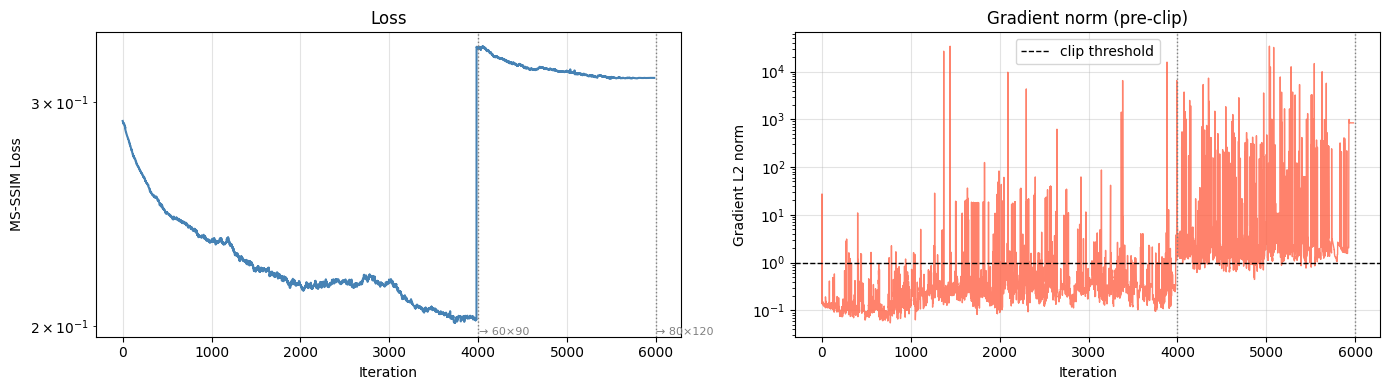

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(losses, color="steelblue", linewidth=1.5)
ax1.set_xlabel("Iteration")
ax1.set_ylabel("MS-SSIM Loss")
ax1.set_title("Loss")
ax1.set_yscale("log")
ax1.grid(True, alpha=0.35)

ax2.plot(grad_norms[: len(losses)], color="tomato", linewidth=1.0, alpha=0.8)
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Gradient L2 norm")
ax2.set_title("Gradient norm (pre-clip)")
ax2.set_yscale("log")
ax2.axhline(1.0, color="black", linewidth=1.0, linestyle="--", label="clip threshold")
ax2.legend()
ax2.grid(True, alpha=0.35)

# Mark phase boundaries
for boundary, label in zip(
    [phases[0]["steps"], phases[0]["steps"] + phases[1]["steps"]],
    ["→ 60×90", "→ 80×120"],
):
    for ax in (ax1, ax2):
        ax.axvline(boundary, color="gray", linewidth=1.0, linestyle=":")
    ax1.text(boundary + 5, ax1.get_ylim()[0], label, fontsize=8, color="gray", va="bottom")

plt.tight_layout()
plt.show()

In [ ]:
HIRES = (240, 360)
target_hires = np.array(target_pil.resize((HIRES[1], HIRES[0]), Image.LANCZOS)) / 255.0

final_params = from_normalized(params, metadata, scales)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(target_hires)
axes[0].set_title("Target (lada.png)")
axes[0].axis("off")

axes[1].imshow(np.array(diff_render(free_params, resolution=HIRES)))
axes[1].set_title("Before optimisation")
axes[1].axis("off")

axes[2].imshow(np.array(diff_render(final_params, resolution=HIRES)))
axes[2].set_title(f"After {N_STEPS} steps")
axes[2].axis("off")

plt.suptitle("Inverse rendering: fitting SDF scene to a photograph", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Initial loss: {losses[0]:.5f}")
print(f"Final loss:   {losses[-1]:.5f}")
print(f"Improvement:  {losses[0]/losses[-1]:.1f}\u00d7")

In [10]:
# ── Export optimisation trajectory as GIF ─────────────────────────────────────
frames = []
for step in sorted(snapshots.keys()):
    frame = (np.clip(snapshots[step], 0, 1) * 255).astype(np.uint8)
    frames.append(frame)

gif_path = "assets/optimization.gif"
imageio.mimsave(gif_path, frames, fps=10, loop=0)
print(f"Saved {gif_path}  ({len(frames)} frames, {len(frames) / 3:.1f}s at 3 fps)")

Saved assets/optimization.gif  (301 frames, 100.3s at 3 fps)
